In [1]:
# !pip install nltk pandas matplotlib seaborn pypdf python-docx wordcloud

In [2]:
import nltk
import string
import pandas as pd
import matplotlib.pyplot as plt
from pypdf import PdfReader
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/intellect/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
pdf = PdfReader("ML.pdf")

text = ""

for page in pdf.pages:
    text += page.extract_text()

print(text[:1000])

Machine Learning - Overview
Machine Learning (ML) is a branch of Artificial Intelligence (AI) that enables computers to learn from
data and improve their performance without being explicitly programmed for every task. Instead of
following fixed rules, machine learning systems analyze patterns, identify relationships, and make
predictions or decisions based on the information they receive. ML is widely used in modern
applications such as recommendation systems, fraud detection, medical diagnosis, autonomous
vehicles, speech recognition, natural language processing, and image classification. The learning
process typically involves training a model using historical data, where algorithms discover patterns
and create mathematical representations that can be applied to new, unseen data. There are three
primary types of machine learning: supervised learning, where models learn from labeled data;
unsupervised learning, where models identify hidden structures in unlabeled data; and
reinforceme

In [4]:
print("ORIGINAL DOCUMENT")
print("="*50)
print(text)

ORIGINAL DOCUMENT
Machine Learning - Overview
Machine Learning (ML) is a branch of Artificial Intelligence (AI) that enables computers to learn from
data and improve their performance without being explicitly programmed for every task. Instead of
following fixed rules, machine learning systems analyze patterns, identify relationships, and make
predictions or decisions based on the information they receive. ML is widely used in modern
applications such as recommendation systems, fraud detection, medical diagnosis, autonomous
vehicles, speech recognition, natural language processing, and image classification. The learning
process typically involves training a model using historical data, where algorithms discover patterns
and create mathematical representations that can be applied to new, unseen data. There are three
primary types of machine learning: supervised learning, where models learn from labeled data;
unsupervised learning, where models identify hidden structures in unlabeled dat

In [5]:
words = word_tokenize(text)

print("Total Words:", len(words))

Total Words: 311


In [6]:
sentences = sent_tokenize(text)

print("Total Sentences:", len(sentences))

Total Sentences: 10


In [7]:
avg_sentence_length = len(words) / len(sentences)

print("Average Sentence Length:", round(avg_sentence_length,2))

Average Sentence Length: 31.1


In [8]:
stop_words = set(stopwords.words('english'))

clean_words = []

for word in words:
    
    word = word.lower()
    
    if word not in string.punctuation:
        
        if word not in stop_words:
            
            clean_words.append(word)

print(clean_words)


['machine', 'learning', 'overview', 'machine', 'learning', 'ml', 'branch', 'artificial', 'intelligence', 'ai', 'enables', 'computers', 'learn', 'data', 'improve', 'performance', 'without', 'explicitly', 'programmed', 'every', 'task', 'instead', 'following', 'fixed', 'rules', 'machine', 'learning', 'systems', 'analyze', 'patterns', 'identify', 'relationships', 'make', 'predictions', 'decisions', 'based', 'information', 'receive', 'ml', 'widely', 'used', 'modern', 'applications', 'recommendation', 'systems', 'fraud', 'detection', 'medical', 'diagnosis', 'autonomous', 'vehicles', 'speech', 'recognition', 'natural', 'language', 'processing', 'image', 'classification', 'learning', 'process', 'typically', 'involves', 'training', 'model', 'using', 'historical', 'data', 'algorithms', 'discover', 'patterns', 'create', 'mathematical', 'representations', 'applied', 'new', 'unseen', 'data', 'three', 'primary', 'types', 'machine', 'learning', 'supervised', 'learning', 'models', 'learn', 'labeled', 

In [9]:
word_freq = Counter(clean_words)

top_words = word_freq.most_common(10)

df = pd.DataFrame(top_words,
                  columns=["Word","Frequency"])

df

,Word,Frequency
0,learning,12
1,data,9
2,machine,7
3,ml,3
4,learn,3
5,model,3
6,models,3
7,artificial,2
8,intelligence,2
9,systems,2


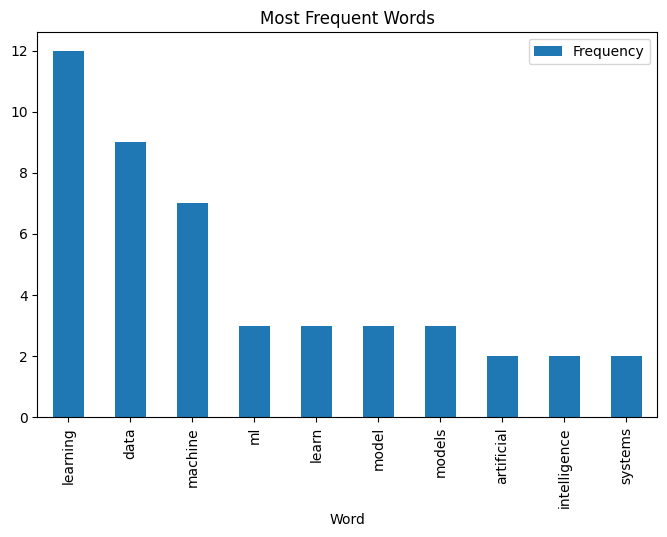

In [10]:
df.plot(
    x="Word",
    y="Frequency",
    kind="bar",
    figsize=(8,5)
)

plt.title("Most Frequent Words")
plt.show()

In [11]:
word_frequencies = {}

for word in clean_words:
    
    if word not in word_frequencies:
        word_frequencies[word] = 1
        
    else:
        word_frequencies[word] += 1

word_frequencies

{'machine': 7,
 'learning': 12,
 'overview': 1,
 'ml': 3,
 'branch': 1,
 'artificial': 2,
 'intelligence': 2,
 'ai': 1,
 'enables': 1,
 'computers': 1,
 'learn': 3,
 'data': 9,
 'improve': 1,
 'performance': 1,
 'without': 1,
 'explicitly': 1,
 'programmed': 1,
 'every': 1,
 'task': 1,
 'instead': 1,
 'following': 1,
 'fixed': 1,
 'rules': 1,
 'systems': 2,
 'analyze': 1,
 'patterns': 2,
 'identify': 2,
 'relationships': 1,
 'make': 1,
 'predictions': 1,
 'decisions': 1,
 'based': 1,
 'information': 1,
 'receive': 1,
 'widely': 1,
 'used': 1,
 'modern': 1,
 'applications': 1,
 'recommendation': 1,
 'fraud': 1,
 'detection': 1,
 'medical': 1,
 'diagnosis': 1,
 'autonomous': 1,
 'vehicles': 1,
 'speech': 1,
 'recognition': 1,
 'natural': 1,
 'language': 1,
 'processing': 1,
 'image': 1,
 'classification': 1,
 'process': 1,
 'typically': 1,
 'involves': 1,
 'training': 2,
 'model': 3,
 'using': 1,
 'historical': 1,
 'algorithms': 2,
 'discover': 1,
 'create': 1,
 'mathematical': 1,
 'repr

In [12]:
max_frequency = max(word_frequencies.values())

for word in word_frequencies:
    
    word_frequencies[word] = (
        word_frequencies[word] / max_frequency
    )

word_frequencies

{'machine': 0.5833333333333334,
 'learning': 1.0,
 'overview': 0.08333333333333333,
 'ml': 0.25,
 'branch': 0.08333333333333333,
 'artificial': 0.16666666666666666,
 'intelligence': 0.16666666666666666,
 'ai': 0.08333333333333333,
 'enables': 0.08333333333333333,
 'computers': 0.08333333333333333,
 'learn': 0.25,
 'data': 0.75,
 'improve': 0.08333333333333333,
 'performance': 0.08333333333333333,
 'without': 0.08333333333333333,
 'explicitly': 0.08333333333333333,
 'programmed': 0.08333333333333333,
 'every': 0.08333333333333333,
 'task': 0.08333333333333333,
 'instead': 0.08333333333333333,
 'following': 0.08333333333333333,
 'fixed': 0.08333333333333333,
 'rules': 0.08333333333333333,
 'systems': 0.16666666666666666,
 'analyze': 0.08333333333333333,
 'patterns': 0.16666666666666666,
 'identify': 0.16666666666666666,
 'relationships': 0.08333333333333333,
 'make': 0.08333333333333333,
 'predictions': 0.08333333333333333,
 'decisions': 0.08333333333333333,
 'based': 0.08333333333333333

In [13]:
sentences = sent_tokenize(text)
print("Total Sentences:", len(sentences))

Total Sentences: 10


In [14]:
sentence_scores = {
    sentence: sum(
        word_frequencies.get(word, 0)
        for word in word_tokenize(sentence.lower())
    )
    for sentence in sentences
}

In [15]:
ranked_sentences = sorted(
    sentence_scores.items(),
    key=lambda x: x[1],
    reverse=True
)
for rank, (sentence, score) in enumerate(ranked_sentences, start=1):
    print(f"Rank {rank}")
    print("Sentence:", sentence)
    print("Score:", round(score, 2))
    print()

Rank 1
Sentence: There are three
primary types of machine learning: supervised learning, where models learn from labeled data;
unsupervised learning, where models identify hidden structures in unlabeled data; and
reinforcement learning, where agents learn through rewards and penalties while interacting with an
environment.
Score: 8.5

Rank 2
Sentence: Machine Learning - Overview
Machine Learning (ML) is a branch of Artificial Intelligence (AI) that enables computers to learn from
data and improve their performance without being explicitly programmed for every task.
Score: 5.75

Rank 3
Sentence: Popular machine learning algorithms include Linear Regression, Decision Trees,
Random Forests, Support Vector Machines, K-Nearest Neighbors, Neural Networks, and Deep
Learning models.
Score: 4.33

Rank 4
Sentence: The learning
process typically involves training a model using historical data, where algorithms discover patterns
and create mathematical representations that can be applied to new, u

In [17]:
summary_percent = int(
    input("Enter Summary Percentage: ")
)

summary_length = int(
    len(sentences) * summary_percent / 100
)

top_sentences = ranked_sentences[:summary_length]

summary_sentences = []

for sentence, score in top_sentences:
    
    summary_sentences.append(sentence)

summary = " ".join(summary_sentences)

print("SUMMARY")
print("="*50)
print(summary)

SUMMARY
There are three
primary types of machine learning: supervised learning, where models learn from labeled data;
unsupervised learning, where models identify hidden structures in unlabeled data; and
reinforcement learning, where agents learn through rewards and penalties while interacting with an
environment. Machine Learning - Overview
Machine Learning (ML) is a branch of Artificial Intelligence (AI) that enables computers to learn from
data and improve their performance without being explicitly programmed for every task. Popular machine learning algorithms include Linear Regression, Decision Trees,
Random Forests, Support Vector Machines, K-Nearest Neighbors, Neural Networks, and Deep
Learning models. The learning
process typically involves training a model using historical data, where algorithms discover patterns
and create mathematical representations that can be applied to new, unseen data. As technology continues to evolve, machine learning is transforming industries
by auto

In [18]:
original_words = len(word_tokenize(text))
summary_words = len(word_tokenize(summary))

compression_ratio = (
    summary_words / original_words
) * 100

print("Original Words :", original_words)
print("Summary Words :", summary_words)
print("Compression Ratio :", round(compression_ratio,2),"%")

Original Words : 311
Summary Words : 225
Compression Ratio : 72.35 %
